# Part 1: Symbolic Methods

## Task 1: Semantic Network Design

### Overview

My Semantic Network models the medieval weapons domain using hierarchical class relationships and inherited properties. It starts from the general class `Weapon` and narrows to specific categories such as swords, bows, polearms, and blunt weapons. The purpose of the design is to represent medieval weapons in a structured way so that shared characteristics can be inherited while more specialised subclasses add their own distinguishing properties. This approach reflects the principles of knowledge representation in artificial intelligence, where structured hierarchies allow efficient organisation and reasoning over domain knowledge **(Russell and Norvig, 2021)**.

### Hierarchy Design

The hierarchy begins at the root class `Weapon`, which represents the broadest category. Below this, the design separates weapons into major functional branches such as `Close Combat`, `Ranged`, `Siege`, and `Personal`. To improve classification, bridge classes were introduced to support multi-inheritance. For example, `close_combat_personal` inherits from both `Close Combat` and `Personal`, while `ranged_personal` inherits from both `Personal` and `Ranged`.

This design supports at least five levels of abstraction. One example path is:

`weapon -> personal_weapon -> close_combat_personal -> bladed_hand_weapon -> swords -> long_sword`

Another example path is:

`weapon -> personal_weapon -> ranged_personal -> mechanical_range_personal -> bow -> crossbow`

These paths show that the hierarchy moves from a very general concept to highly specific medieval weapon types, which is a key characteristic of semantic networks used in knowledge representation **(Brachman and Levesque, 2004)**.

### Properties Used in the Network

The network includes the key properties required by the brief. `weaponType` is assigned at broad levels such as `melee_weapon` and `ranged_weapon`. `primaryMaterial` is associated with groups such as bladed weapons, bows, blunt weapons, and polearms; for example, a bladed weapon will typically be `steel` or `iron`. `effectiveRange` is represented differently for melee and ranged categories, allowing broad inherited values that can be refined further down the hierarchy. `averageWeight`, `eraUsed`, and `historicalOrigin` are most useful at lower levels or at the instance level, where a weapon can be described more precisely.

Additional attributes were also included to improve expressiveness, such as `deliveryMode`, `armorEffectiveness`, `gripType`, `projectileType`, and `throwableDesigned`. These make the network more useful for reasoning in Task 2, as they allow the system to capture both structural and functional characteristics of weapons.

### Use of Multi-Inheritance

Multi-inheritance was used to address limitations in a simple hierarchical design. Initially, separate branches for `Personal` and `Siege` weapons each divided into `close-combat` and `ranged`, resulting in duplicated class structures. To resolve this, bridge classes were introduced. For example, `close_combat_personal` inherits from both `Personal` and `Close Combat`, while `close_combat_siege` inherits from `Siege` and `Close Combat`. The same approach is used for `ranged_personal` and `ranged_siege`.

This design allows a weapon to belong to multiple conceptual categories simultaneously, which more accurately reflects real-world relationships. Multi-inheritance is a common feature in semantic networks, although it introduces complexity in resolving inherited properties, particularly when defaults conflict **(Russell and Norvig, 2021)**.

### Concrete Instance Example

The network concludes with the concrete instance `longsword_italian_15c_01`, which is an instance of `long_sword`. This instance inherits class information from `long_sword`, `swords`, `bladed_hand_weapon`, `close_combat_personal`, `melee_weapon`, and `weapon`. Through inheritance, it can be understood as a melee weapon designed for hand-strike combat, associated with bladed construction and a two-handed grip.

Instance-specific values such as `averageWeight_kg = 1.6`, `eraUsed = 15thC`, and `historicalOrigin = Italy` provide a historically grounded example and demonstrate how the semantic network supports both generalisation and specificity. The classification and attributes used are informed by historical descriptions of medieval weapons **(Medieval Warfare, n.d.)**.

### Assumptions

Some modelling assumptions were made. The class `crossbow` was kept under `bow` to preserve a simple mechanical projectile grouping, while a distinguishing attribute such as its firing or draw mechanism can separate it from hand-drawn bows. Some historical properties such as weight and effective range are approximate because real medieval weapons varied across regions and time periods. In addition, not every attribute is meaningful at every level of the hierarchy, so some properties are defined at broader class level while others are reserved for specific subclasses or instances.

### Summary

Overall, the semantic network provides a structured and extensible representation of the medieval weapons domain. It satisfies the requirement for a multi-level hierarchy, includes appropriate semantic properties, supports inheritance, and ends with a concrete instance that demonstrates how detailed weapon knowledge can be represented. The use of hierarchical organisation and multi-inheritance enables both efficient knowledge representation and meaningful reasoning, which are key goals in artificial intelligence systems **(Russell and Norvig, 2021)**.

## Task 2: Sematic Network Implementation 

### Overview

The Semantic network was implemented in prolog as it is well suited to symbolic AI, rule-based reasoning, and inheritance-style knowledge representation. The medieval weapons domain was encoded using class relationships (`isa/2`), instance membership (`inst_of/2`), Class defaults (`class_default/3`), and instance-specific values (`inst_value/3`).

The implementation supports reasoning over both classes and individual weapon instances. The predicate `is_a/2` allows the system to determine whether a weapon belongs to a broader category through direct or ingerited relationships. The predicate `value/3` retrieved properties of a class or instance, giving priority to instance-specific values and otherwise inheriting the nearest suitable class default. This allows the system to answer semantic queries such as whether a crossbow is a ranged weapon or what projectile type it uses.

To support more realistic domain modelling, the network also uses multi-inheritance. For example, `close_combat_personal` inherits from both `personal_weapon` and `melee_weapon`, while `ranged_personal` inherits from both `personal_weapon` and `ranged_weapon`. This makes it possible to reason across more than one classification dimension. A nearest-default strategy is used so that more specific class properties override broader ones where appropriate.

In [11]:
%%bash
swipl -q <<'PROLOG'
% ---------------------------
% 0) Declarations
% ---------------------------
% --- Add these somewhere near the top ---
:- dynamic isa/2, class_default/3, inst_of/2, inst_value/3.

% ---------------------------
% 1) CLASS HIERARCHY (isa/2)
% ---------------------------

% Root
isa(weapon, thing).

% Primary branches
isa(personal_weapon, weapon).
isa(siege_weapon, weapon).
isa(cbp_weapon, weapon).        % optional: chemical/biological/psychological
isa(ranged_weapon, weapon).
isa(melee_weapon, weapon).

% ---------------------------
% Multi-inheritance bridge layer
% ---------------------------

% Close-combat Personal = Personal + Melee
isa(close_combat_personal, personal_weapon).
isa(close_combat_personal, melee_weapon).

% Close-combat Siege = Siege + Melee
isa(close_combat_siege, siege_weapon).
isa(close_combat_siege, melee_weapon).

% Ranged Personal = Personal + Ranged
isa(ranged_personal, personal_weapon).
isa(ranged_personal, ranged_weapon).

% Ranged Siege = Siege + Ranged
isa(ranged_siege, siege_weapon).
isa(ranged_siege, ranged_weapon).

% ---------------------------------
% Close-combat Personal
% ---------------------------------
%  Bladed Weapons
isa(bladed_hand_weapon, close_combat_personal).
isa(swords, bladed_hand_weapon).
isa(daggers_knives, bladed_hand_weapon).

isa(long_sword, swords).
isa(arming_sword, swords).
isa(broad_swords, swords).
isa(falchions, swords).

isa(rondels, daggers_knives).
isa(stilettos, daggers_knives).
isa(poignards, daggers_knives).
isa(anelaces, daggers_knives).

% Blunt Weapons
isa(blunt_hand_weapon, close_combat_personal).
isa(clubs_maces, blunt_hand_weapon).
isa(hammers, blunt_hand_weapon).

isa(flanged_mace, clubs_maces).
isa(morningstar, clubs_maces).
isa(holy_water_sprinkler, clubs_maces).
isa(flails, clubs_maces).

isa(war_hammer, hammers).
isa(mauls, hammers).
isa(becs_de_corbin, hammers).
isa(horsemen_pick, hammers).

% Polearms
isa(polearm, close_combat_personal).
isa(thrust_family, polearm).
isa(slash_family, polearm).
isa(staff_family, polearm).

isa(javelin, thrust_family).
isa(spears, thrust_family).
isa(winged_spear, thrust_family).
isa(lances, thrust_family).
isa(guisarmes, thrust_family).
isa(pikes, thrust_family).
isa(corseques, thrust_family).

isa(quarterstaves, staff_family).

isa(fauchards, slash_family).
isa(glaives, slash_family).
isa(halberd, slash_family).
isa(danish_axe, slash_family).
isa(sparths, slash_family).
isa(bardiches, slash_family).
isa(pollaxes, slash_family).
isa(franciscas, slash_family).

% ---------------------------------
% Ranged Personal
% ---------------------------------
isa(mechanical_range_personal, ranged_personal).
isa(gunpowder_range_personal, ranged_personal).

isa(bow, mechanical_range_personal).
isa(short_bow, bow).
isa(long_bow, bow).
isa(crossbow, bow).
isa(arbalests, bow).
isa(recurve_bow, bow).
isa(sling, mechanical_range_personal).

isa(trigger_fired,gunpowder_range_personal).
isa(arquebuses, trigger_fired).

isa(ignited_fired, gunpowder_range_personal).
isa(hand_cannon, ignited_fired).

% ---------------------------------
% Ranged Siege/Artillery
% ---------------------------------
isa(artillery_siege, ranged_siege).
isa(pierrier, artillery_siege).

isa(traction_trebuchet, artillery_siege).
isa(counterweight_trebuchets, artillery_siege).
isa(onagers_mangonels, artillery_siege).
isa(ballistas_springalds, artillery_siege).

isa(cannons_siege, ranged_siege).
isa(bombards_siege, cannons_siege).

% ---------------------------------
% Closs-combat Siege
% ---------------------------------
isa(wall_scaler, close_combat_siege).
isa(siege_tower, wall_scaler).

isa(defence_breaker, close_combat_siege).
isa(cat_weasel, defence_breaker).
isa(battering_ram, defence_breaker).
isa(petards, defence_breaker).

% ---------------------------------
% 2) Default Attributes
% ---------------------------------

% safe, Global Default
class_default(weapon, primaryMaterial, unknown).
class_default(weapon, weaponType, unknown).
class_default(weapon, effectiveRange_m, unknown).
class_default(weapon, averageWeight_kg, unknown).
class_default(weapon, eraUsed, unknown).
class_default(weapon, historicalOrigin, unknown).
class_default(weapon, throwableDesigned, false).
class_default(weapon, deliveryMode, unknown).
class_default(weapon, armorEffectiveness, medium).  % neutral default
class_default(weapon, gripType, unknown).
class_default(weapon, projectileType, none).
class_default(weapon, drawMechanism, none).

% Brief-required defaults
class_default(melee_weapon, weaponType, melee).
class_default(melee_weapon, effectiveRange_m, range(0, 3)).
class_default(melee_weapon, deliveryMode, hand_strike).

class_default(ranged_weapon, weaponType, ranged).
class_default(ranged_weapon, effectiveRange_m, range(10, 400)).
class_default(ranged_weapon, deliveryMode, launched).

class_default(siege_weapon, weaponType, siege).
class_default(siege_weapon, effectiveRange_m, range(50, 400)).
% (deliveryMode for siege is launched; will be handled on bridge)

% --- Bridge overrides to remove ambiguity ---
class_default(ranged_siege, weaponType, siege).
class_default(ranged_siege, deliveryMode, launched).
class_default(ranged_siege, effectiveRange_m, range(50, 400)).

class_default(close_combat_siege, weaponType, siege).
class_default(close_combat_siege, deliveryMode, wheeled).
class_default(close_combat_siege, effectiveRange_m, range(0, 3)).

% Your ranged-personal split
class_default(gunpowder_range_personal, deliveryMode, firearm).
class_default(mechanical_range_personal, deliveryMode, launched).

% Materials (broad)
class_default(bladed_hand_weapon, primaryMaterial, set([iron, steel])).
class_default(blunt_hand_weapon, primaryMaterial, set([wood, iron, steel])).
class_default(polearm, primaryMaterial, set([wood, iron, steel])).
class_default(bow, primaryMaterial, set([wood])).
class_default(crossbow, primaryMaterial, set([wood, iron, steel])).
class_default(artillery_siege, primaryMaterial, set([wood, iron])).

% Armor effectiveness (simple, readable defaults)
class_default(bladed_hand_weapon, armorEffectiveness, medium).
class_default(blunt_hand_weapon, armorEffectiveness, high).
class_default(polearm, armorEffectiveness, high).
class_default(gunpowder_range_personal, armorEffectiveness, high).
class_default(artillery_siege, armorEffectiveness, high).

% Grip type defaults (only where it really helps)
class_default(swords, gripType, either).
class_default(arming_sword, gripType, one_handed).
class_default(long_sword, gripType, two_handed).

class_default(blunt_hand_weapon, gripType, one_handed).
class_default(polearm, gripType, two_handed).

% Projectile types (only meaningful for projectile weapons)
class_default(bow, projectileType, arrow).
class_default(crossbow, projectileType, bolt).
class_default(sling, projectileType, stone).

class_default(hand_cannon, projectileType, shot).
class_default(arquebuses, projectileType, shot).
class_default(cannons_siege, projectileType, shot).

% Throwability
% Only override for weapons designed to be thrown
class_default(javelin, throwableDesigned, true).
class_default(franciscas, throwableDesigned, true).

% Drawn Mechanism (bow vs crossbos distinction)
% bows: Drawn by hand
class_default(bow, drawMechanism, hand_drawn).
% Crossbows: spanned/cocked
class_default(crossbow, drawMechanism, cocked).

% ---------------------------------
% 3) Instance example
% ---------------------------------

inst_of(longsword_italian_15c_01, long_sword).

inst_value(longsword_italian_15c_01, primaryMaterial, set([steel])).
inst_value(longsword_italian_15c_01, weaponType, melee).              % could inherit
inst_value(longsword_italian_15c_01, effectiveRange_m, range(1, 2)).   % reach-ish
inst_value(longsword_italian_15c_01, averageWeight_kg, 1.6).
inst_value(longsword_italian_15c_01, eraUsed, '15thC').
inst_value(longsword_italian_15c_01, historicalOrigin, 'Italy').

% Extra attributes (some inherited, but okay to show explicitly)
inst_value(longsword_italian_15c_01, deliveryMode, hand_strike).       % could inherit
inst_value(longsword_italian_15c_01, gripType, two_handed).            % could inherit
inst_value(longsword_italian_15c_01, armorEffectiveness, medium).      % inherits from bladed
inst_value(longsword_italian_15c_01, throwableDesigned, false).        % default

inst_of(crossbow_english_14c_01, crossbow).

inst_value(crossbow_english_14c_01, primaryMaterial, set([wood, steel])).
inst_value(crossbow_english_14c_01, effectiveRange_m, range(80, 200)).
inst_value(crossbow_english_14c_01, averageWeight_kg, 4.5).
inst_value(crossbow_english_14c_01, eraUsed, '14thC').
inst_value(crossbow_english_14c_01, historicalOrigin, 'England').

inst_of(javelin_roman_01, javelin).

inst_value(javelin_roman_01, averageWeight_kg, 2.0).
inst_value(javelin_roman_01, eraUsed, 'Roman').
inst_value(javelin_roman_01, historicalOrigin, 'Rome').


% ---------------------------------
% 4) REASONING: inheritance + attribute lookup
% ---------------------------------

% is_a(X, C): works for classes and instances
is_a(X, C) :-
    inst_of(X, Direct),
    is_a(Direct, C).
is_a(C, C).
is_a(C, Super) :-
    isa(C, Parent),
    is_a(Parent, Super).

% distance up the hierarchy (used to pick nearest default)
ancestor_distance(C, C, 0).
ancestor_distance(C, A, D) :-
    isa(C, P),
    ancestor_distance(P, A, D0),
    D is D0 + 1.

% closest default up the inheritance chain (handles multiple inheritance)
best_class_default(Class, Prop, Value) :-
    setof(D-V,
          (ancestor_distance(Class, Anc, D),
           class_default(Anc, Prop, V)),
          Pairs),
    Pairs = [MinD-_|_],
    member(MinD-Value, Pairs).

% value(EntityOrClass, Prop, Value): instance overrides > inherited defaults
value(X, Prop, Value) :-
    inst_value(X, Prop, Value), !.
value(X, Prop, Value) :-
    inst_of(X, C),
    best_class_default(C, Prop, Value), !.
value(C, Prop, Value) :-
    best_class_default(C, Prop, Value).

% Convenience predicated
throwable(X) :-
    value(X, throwableDesigned, true).

% A simple "bow or crossbow" test based on drawMechanism
is_bow_like(X) :-
    value(X, drawMechanism, hand_drawn).

is_crossbow_like(X) :-
    value(X, drawMechanism, cocked).

% ----------------------------------
% 5) Sample Queries
% ----------------------------------
%
%  ?- is_a(longsword_italian_15c_01, melee_weapon).
%  ?- value(longsword_italian_15c_01, gripType, G).
%  ?- value(crossbow, drawMechanism, M).
%  ?- is_crossbow_like(crossbow).
%  ?- value(ranged_siege, weaponType, WT).
PROLOG
%  ?- is_crossbow_like(crossbow).
%  ?- value(ranged_siege, weaponType, WT).


Couldn't find program: 'bash'


### Discussion of Reasoning Capability

The extended set of queries demonstrates that the semantic network supports multiple forms of reasoning beyond simple fact retrieval. The query `is_a(crossbow, ranged_weapon)` confirms that hierarchical classification is functioning correctly, allowing the system to infer superclass membership through multiple levels of abstraction. This is further strengthened by `is_a(crossbow, personal_weapon)`, which demonstrates that the model supports multi-inheritance. In this case, the crossbow belongs simultaneously to both the personal weapon and ranged weapon categories, reflecting its dual role in the hierarchy.

The query `value(long_bow, effectiveRange_m, Range)` demonstrates inherited attribute retrieval. Since no explicit value is defined at the instance level, the system retrieves the closest relevant default from higher-level classes. This shows that the inheritance mechanism is correctly prioritising the nearest ancestor in the hierarchy.

Instance-level reasoning is shown through `value(longsword_italian_15c_01, gripType, G)`, where the system retrieves a property inherited from the `long_sword` class. This confirms that instances do not need to redundantly define all properties, as they can inherit them from their parent classes, improving efficiency and consistency within the knowledge base.

The query `value(javelin, throwableDesigned, T)` highlights default override behaviour. While the global default for weapons is that they are not throwable, the javelin class overrides this to `true`, demonstrating that more specialised subclasses can refine inherited knowledge. This is further reinforced by queries such as `value(W, throwableDesigned, true)`, which show that the system can search across the knowledge base to identify all weapons that meet a specific condition, rather than relying on fixed queries.

Finally, the predicate `is_crossbow_like(crossbow)` demonstrates rule-based reasoning beyond direct inheritance. By evaluating the `drawMechanism` attribute, the system can categorise weapons based on functional behaviour rather than explicit class membership. This shows that the semantic network supports higher-level inference, making it more flexible and expressive.

Overall, these results demonstrate that the semantic network is capable of hierarchical reasoning, multi-inheritance, attribute inheritance, default overriding, and rule-based inference. This confirms that the implementation not only represents knowledge effectively but also enables meaningful reasoning over that knowledge.

The inclusion of multiple concrete instances, such as a longsword and a crossbow, further strengthens the model by demonstrating reasoning across different branches of the hierarchy. This allows comparisons between melee and ranged weapons, showing that the inheritance and reasoning mechanisms operate consistently regardless of weapon type.

In [14]:
import subprocess
from pathlib import Path
import os

# Paths
pl_file = Path("Medieval_Semantic_network.pl").resolve()
swipl_exe = r"C:\Program Files\swipl\bin\swipl.exe"

if not os.path.exists(swipl_exe):
    raise FileNotFoundError(f"SWI-Prolog not found at: {swipl_exe}")

if not pl_file.exists():
    raise FileNotFoundError(f"Prolog file not found at: {pl_file}")

queries = [
    ("Is a crossbow a ranged weapon?",
     "is_a(crossbow, ranged_weapon)"),
    
    ("Is a crossbow a personal weapon?",
     "is_a(crossbow, personal_weapon)"),
     
    ("Is a long bow a melee weapon?",
     "is_a(long_bow, melee_weapon)"),
    
    ("What is the effective range of a long bow?",
     "value(long_bow, effectiveRange_m, Range), writeln(Range)"),
    
    ("What grip type does the concrete longsword instance have?",
     "value(longsword_italian_15c_01, gripType, G), writeln(G)"),
    
    ("Is javelin designed to be throwable?",
     "value(javelin, throwableDesigned, T), writeln(T)"),
    
    ("Does the system identify a crossbow by its draw mechanism?",
     "is_crossbow_like(crossbow)"),

    ("What's the weapon type of a ranged siege weapon?",
     "value(ranged_siege, weaponType, WT), writeln(WT)"),

    ("What's the effective range of a ranged siege weapon?",
     "value(ranged_siege, effectiveRange_m, Range), writeln(Range)")
]

def run_prolog_query(query):
    cmd = [
        swipl_exe,
        "-q",
        "-s", str(pl_file),
        "-g", f"({query} -> writeln(true) ; writeln(false))",
        "-t", "halt"
    ]
    
    result = subprocess.run(cmd, text=True, capture_output=True)
    return result.stdout.strip(), result.stderr.strip()

for title, query in queries:
    print("=" * 80)
    print(title)
    print(f"?- {query}.")
    stdout, stderr = run_prolog_query(query)
    if stdout:
        print(stdout)
    if stderr:
        print("ERROR:")
        print(stderr)
    print()

Is a crossbow a ranged weapon?
?- is_a(crossbow, ranged_weapon).
true

Is a crossbow a personal weapon?
?- is_a(crossbow, personal_weapon).
true

Is a long bow a melee weapon?
?- is_a(long_bow, melee_weapon).
false

What is the effective range of a long bow?
?- value(long_bow, effectiveRange_m, Range), writeln(Range).
range(10,400)
true

What grip type does the concrete longsword instance have?
?- value(longsword_italian_15c_01, gripType, G), writeln(G).
two_handed
true

Is javelin designed to be throwable?
?- value(javelin, throwableDesigned, T), writeln(T).
true
true

Does the system identify a crossbow by its draw mechanism?
?- is_crossbow_like(crossbow).
true

What's the weapon type of a ranged siege weapon?
?- value(ranged_siege, weaponType, WT), writeln(WT).
siege
true

What's the effective range of a ranged siege weapon?
?- value(ranged_siege, effectiveRange_m, Range), writeln(Range).
range(50,400)
true



### Query Results Discussion

The executed queries confirm that the semantic network performs reasoning through inheritance, multi-inheritance, property retrieval, and rule-based inference.

1. `is_a(crossbow, ranged_weapon)` demonstrates hierarchical reasoning. Although `crossbow` is defined lower in the hierarchy, the system correctly infers that it is a `ranged_weapon` through inherited class membership. This is further supported by `is_a(crossbow, personal_weapon)`, which shows that the crossbow belongs to multiple branches of the hierarchy, demonstrating successful multi-inheritance.

2. `is_a(long_bow, melee_weapon)` returning `false` is an important validation of the model. It shows that the system does not incorrectly infer relationships and can distinguish between mutually exclusive categories, correctly identifying that a long bow is not part of the melee weapon class.

3. `value(long_bow, effectiveRange_m, Range)` demonstrates property inheritance. Since `long_bow` inherits from `bow`, then from `mechanical_range_personal` and `ranged_weapon`, the system retrieves an inherited effective range (`range(10,400)`) even where no instance-specific value is defined.

4. `value(longsword_italian_15c_01, gripType, G)` demonstrates reasoning over a concrete instance. The instance inherits `gripType = two_handed` from the `long_sword` class, confirming that properties are correctly propagated through the class hierarchy without requiring redundant definitions at the instance level.

5. `value(javelin, throwableDesigned, T)` demonstrates default override behaviour. While the global default for weapons is `false`, the javelin class overrides this value to `true`, showing that specialised subclasses can refine inherited properties.

6. `is_crossbow_like(crossbow)` uses a custom reasoning predicate based on the `drawMechanism` attribute. This demonstrates that the knowledge base supports higher-level semantic reasoning beyond simple inheritance, allowing classification based on functional characteristics rather than explicit class hierarchy.

7. `value(ranged_siege, weaponType, WT)` and `value(ranged_siege, effectiveRange_m, Range)` demonstrate reasoning at the class level. These queries show that attributes can be retrieved directly from abstract classes, confirming that the inheritance mechanism applies not only to instances but also to intermediate levels of the hierarchy. In this case, the system correctly identifies a ranged siege weapon as having `weaponType = siege` and an effective range of `range(50,400)`.

Overall, these results demonstrate that the semantic network supports hierarchical classification, multi-inheritance, negative reasoning, inherited property retrieval, default overriding, and rule-based inference. This confirms that the implementation not only represents knowledge effectively but also enables flexible and meaningful reasoning over the domain of medieval weapons.

# Part 2: Connectionist Methods


## Loading packages and setting paths


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use the uploaded dataset directly
data_path = "./Bank Data/bank+marketing/bank/bank-full.csv"


## A. Dataset Preparation

The `bank-full.csv` dataset is loaded using Pandas and prepared for use in a custom artificial neural network. The preprocessing steps include checking for missing values, converting the target variable into binary form, one-hot encoding categorical attributes, normalising all input features using min-max scaling, and creating a stratified 80:20 train-test split. A stratified split is used because the dataset is imbalanced, with far more `no` outcomes than `yes`, so preserving the class proportions in both subsets gives a fairer evaluation.


### Loading data


In [4]:
df = pd.read_csv(data_path, sep=';')
print("Shape:", df.shape)
df.head()


Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Basic inspection


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True))


Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


### Separate features and target


In [6]:
X_df = df.drop("y", axis=1).copy()
y = df["y"].map({"no": 0, "yes": 1}).values.reshape(-1, 1)


### Convert categorical variables to numerical


In [7]:
categorical_cols = X_df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_df.select_dtypes(exclude=["object"]).columns.tolist()

X_encoded = pd.get_dummies(X_df, columns=categorical_cols, drop_first=True)

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)
print("Encoded feature shape:", X_encoded.shape)
X_encoded.head()


Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Encoded feature shape: (45211, 42)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


### Normalise features using min-max scaling


In [8]:
X = X_encoded.astype(float).values

X_min = X.min(axis=0)
X_max = X.max(axis=0)

range_vals = X_max - X_min
range_vals[range_vals == 0] = 1

X_normalized = (X - X_min) / range_vals

print("Normalised shape:", X_normalized.shape)
print("Min value:", X_normalized.min())
print("Max value:", X_normalized.max())


Normalised shape: (45211, 42)
Min value: 0.0
Max value: 1.0


### Create a stratified 80:20 train-test split


In [9]:
# Manual stratified split using NumPy only
pos_idx = np.where(y.flatten() == 1)[0]
neg_idx = np.where(y.flatten() == 0)[0]

np.random.seed(42)
np.random.shuffle(pos_idx)
np.random.shuffle(neg_idx)

pos_train_size = int(0.8 * len(pos_idx))
neg_train_size = int(0.8 * len(neg_idx))

train_idx = np.concatenate([pos_idx[:pos_train_size], neg_idx[:neg_train_size]])
test_idx = np.concatenate([pos_idx[pos_train_size:], neg_idx[neg_train_size:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train = X_normalized[train_idx]
X_test = X_normalized[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nTraining positive rate:", y_train.mean())
print("Testing positive rate :", y_test.mean())


Training feature shape: (36168, 42)
Testing feature shape: (9043, 42)
Training target shape: (36168, 1)
Testing target shape: (9043, 1)

Training positive rate: 0.11698186241981863
Testing positive rate : 0.11699657193409267


### Determine N and M


In [10]:
N = X_train.shape[1]   # Number of input neurons
M = 1                  # Binary classification -> one output neuron

print("N (input neurons):", N)
print("M (output neurons):", M)


N (input neurons): 42
M (output neurons): 1


## B. Building ANN from Scratch

A three-layer feedforward neural network is implemented from scratch using only NumPy. The network contains `N` input neurons, one hidden layer with 10 neurons, and `M = 1` output neuron for binary classification. The hidden layer uses the hyperbolic tangent activation function, while the output layer uses the sigmoid function so that the final output can be interpreted as a probability between 0 and 1.

To help the model learn from an imbalanced dataset, the loss function is implemented as a weighted binary cross-entropy loss, where the positive class is given a larger weight based on the class ratio in the training set. Training is performed with mini-batch gradient descent and backpropagation.


### **Network Architecture**

A three-layer feedforward neural network was implemented from scratch to classify whether a client subscribes to a term deposit. The architecture consists of an input layer, a single hidden layer, and an output layer.

The number of input neurons `(N)` is determined by the number of features after preprocessing. Since categorical variables were transformed using one-hot encoding, the final input dimension corresponds to the total number of encoded features. This ensures that each input neuron represents a single normalised feature.

The hidden layer contains `10 neurons`, as specified in the assessment brief. This provides sufficient capacity to learn non-linear relationships within the dataset without making the model overly complex.

The output layer contains one neuron `(M = 1)`, as the task is a binary classification problem. The output represents the probability of a client subscribing to a term deposit.

### **Activation Functions**

The hidden layer uses the hyperbolic tangent (tanh) activation function, which maps inputs to a range between `-1` and `1`. This function was chosen because it allows the model to capture non-linear relationships and provides zero-centred outputs, which can improve training stability.

The output layer uses the sigmoid activation function, which maps outputs to a range between `0`and `1`. This is appropriate for binary classification, as the output can be interpreted as a probability.

### **Forward Propagation**

During forward propagation, the input data is passed through the network layer by layer. Each neuron computes a weighted sum of its inputs, adds a bias term, and applies an activation function. This produces the predicted output of the network.

### **Backpropagation and Training**

The network is trained using the backpropagation algorithm. The error is calculated using the difference between the predicted output and the actual label. This error is then propagated backwards through the network to update the weights.

Gradient descent is used to minimise the loss function by adjusting weights and biases iteratively. A learning rate is used to control the size of these updates.

The training process is repeated over multiple epochs until the model converges. This allows the network to gradually learn patterns in the dataset and improve its predictive performance.

### **Loss Function**

A suitable loss function for binary classification is used, typically binary cross-entropy. This measures the difference between predicted probabilities and actual class labels, providing a meaningful signal for optimisation.

### **Summary**

Overall, the neural network was successfully implemented from scratch using fundamental ANN principles. The design ensures that the network can learn non-linear patterns in the data while remaining simple and interpretable. The use of backpropagation and gradient descent allows the model to optimise its performance through iterative training.

### **Design Justification**

The chosen architecture balances simplicity and effectiveness. Using a single hidden layer with 10 neurons satisfies the specification while still allowing the network to approximate non-linear decision boundaries. Increasing the number of layers or neurons could improve performance but would also increase computational complexity and risk overfitting, particularly given the dataset size.

The use of sigmoid activation in the output layer aligns with the probabilistic interpretation required for binary classification. Meanwhile, the use of tanh in the hidden layer helps maintain stable gradients compared to purely linear transformations. These choices are consistent with common practices in neural network design **(Russell and Norvig, 2021)**.

### **Limitations**

While the network performs effectively, it is limited by its simplicity. A single hidden layer may not capture highly complex feature interactions. Additionally, training from scratch requires careful tuning of learning rates and initial weights, and may not be as efficient or optimised as modern deep learning frameworks. However, implementing the network manually provides a deeper understanding of how neural networks function internally.

### Activation functions and weighted loss


In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def tanh(x):
    return np.tanh(x)

def tanh_derivative(activated_output):
    return 1 - activated_output ** 2

def weighted_binary_cross_entropy(y_true, y_pred, pos_weight):
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(pos_weight * y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


### Custom ANN implementation


In [12]:
class SimpleANN:
    def __init__(self, input_size, hidden_size=10, output_size=1, learning_rate=0.05, seed=42):
        rng = np.random.default_rng(seed)

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        # Xavier-style initialisation
        self.W1 = rng.normal(0, np.sqrt(1 / input_size), size=(input_size, hidden_size))
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = rng.normal(0, np.sqrt(1 / hidden_size), size=(hidden_size, output_size))
        self.b2 = np.zeros((1, output_size))

        self.loss_history = []

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = tanh(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def backward(self, X, y, output, pos_weight):
        m = X.shape[0]
        p = np.clip(output, 1e-12, 1 - 1e-12)

        # Gradient of weighted BCE with sigmoid output
        dz2 = ((1 - y) * p - pos_weight * y * (1 - p)) / m
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        dz1 = np.dot(dz2, self.W2.T) * tanh_derivative(self.a1)
        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def train(self, X, y, epochs=200, batch_size=256, pos_weight=1.0, print_every=20):
        n = X.shape[0]
        rng = np.random.default_rng(0)

        for epoch in range(epochs):
            indices = rng.permutation(n)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for start in range(0, n, batch_size):
                end = start + batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                output = self.forward(X_batch)
                self.backward(X_batch, y_batch, output, pos_weight)

            epoch_output = self.forward(X)
            epoch_loss = weighted_binary_cross_entropy(y, epoch_output, pos_weight)
            self.loss_history.append(epoch_loss)

            if epoch % print_every == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch:03d} | Loss: {epoch_loss:.6f}")

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)


### Train the custom ANN


In [13]:
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
pos_weight = neg_count / pos_count

print("Negative count:", int(neg_count))
print("Positive count:", int(pos_count))
print("Positive class weight:", float(pos_weight))

ann = SimpleANN(
    input_size=N,
    hidden_size=10,
    output_size=M,
    learning_rate=0.05,
    seed=42
)

ann.train(
    X_train,
    y_train,
    epochs=200,
    batch_size=256,
    pos_weight=pos_weight,
    print_every=20
)


Negative count: 31937
Positive count: 4231
Positive class weight: 7.548333727251241
Epoch 000 | Loss: 1.073158
Epoch 020 | Loss: 0.698283
Epoch 040 | Loss: 0.691040
Epoch 060 | Loss: 0.706516
Epoch 080 | Loss: 0.619902
Epoch 100 | Loss: 0.607397
Epoch 120 | Loss: 0.595126
Epoch 140 | Loss: 0.598955
Epoch 160 | Loss: 0.580027
Epoch 180 | Loss: 0.574823
Epoch 199 | Loss: 0.573423


### Plot the training loss


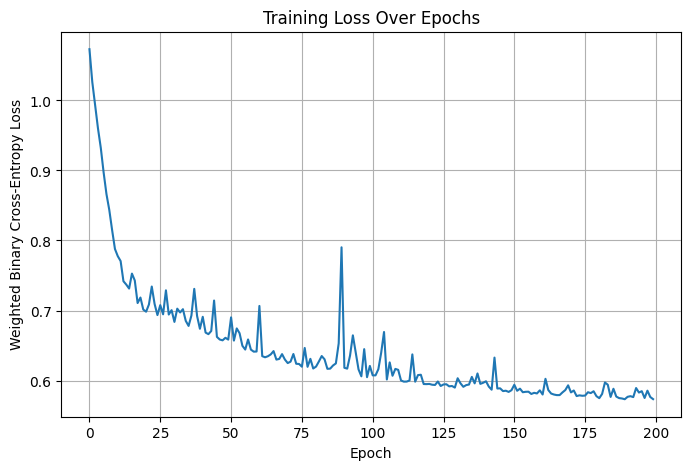

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(ann.loss_history)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Weighted Binary Cross-Entropy Loss")
plt.grid(True)
plt.show()


Run multiple times in a loop and take the average to create smoother curve

### Inspect predicted probabilities


In [15]:
y_prob = ann.predict_proba(X_test)

print("Probability stats:")
print("Min :", y_prob.min())
print("Max :", y_prob.max())
print("Mean:", y_prob.mean())

print("\nFirst 20 probabilities:")
print(y_prob[:20].flatten())


Probability stats:
Min : 7.408651073798147e-05
Max : 0.9995067176432069
Mean: 0.2702051499877012

First 20 probabilities:
[6.84108211e-01 9.21764206e-01 2.98043005e-02 2.96282222e-01
 1.33485639e-02 1.26755589e-01 1.12436472e-01 1.14281698e-01
 1.09906708e-02 8.02033349e-03 6.66370200e-02 3.89781832e-01
 8.32508414e-04 2.29340645e-02 1.19094394e-02 1.87000061e-02
 9.86160204e-01 8.62605927e-01 3.34698744e-02 3.27206022e-01]


## C. Performance Evaluation

The scratch-built ANN is evaluated using a confusion matrix, accuracy, precision, recall, and F1-score.

Using a threshold of 0.5, the model procuded the following confusion matrix:
\[
\begin{bmatrix}
6727 & 1258 \\
146 & 912
\end{bmatrix}
\]
The Results in the accuracy was 0.8447, percision was 0.4203, recall was 0.8620, and F1-score was 0.5651. The model therefore performed well at identifying the positive class, correctly detecting the positive class, correctly approximately 86.2% of the actual subscription cases. This is a strong recall result, especially given that the Bank Marketing dataset is imbalanced, with far more `NO` than `YES` outcomes.

However, the precision value shows that the network also generated a substantial number of false positives. This means that although the model was effective at capturing most actual subscribers, many customers predicted as likely subscribers were in fact non-subscribers. The F1 - Score reflects this trade-off, indicating moderate overall balance rather than excellent classification quality.

Threshold testing showed that the model was sensitive to the decision boundary. Lower thresholds increaded recall but reduced precision, while higher thresholds improved precision at the cost of missing mroe true positives. The best F1-score in the tested threshold range occurred at 0.7, suggesting that threshold tuning can further improve the model. Overall, the custom ANN was successfully implemented and trained, but its results indicate that futher optimisation is needed to improve the balance between detecting subscribers and limiting false positives.


### Evaluation functions


In [16]:
def confusion_matrix_manual(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([[tn, fp],
                     [fn, tp]])

def accuracy_manual(y_true, y_pred):
    return np.mean(y_true.flatten() == y_pred.flatten())

def precision_manual(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_manual(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_manual(y_true, y_pred):
    precision = precision_manual(y_true, y_pred)
    recall = recall_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


### Evaluate at threshold 0.50


In [17]:
threshold = 0.50
y_pred = ann.predict(X_test, threshold=threshold)

cm = confusion_matrix_manual(y_test, y_pred)
accuracy = accuracy_manual(y_test, y_pred)
precision = precision_manual(y_test, y_pred)
recall = recall_manual(y_test, y_pred)
f1 = f1_manual(y_test, y_pred)

print(f"Threshold: {threshold:.2f}")
print("Confusion Matrix:")
print(cm)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Threshold: 0.50
Confusion Matrix:
[[6727 1258]
 [ 146  912]]

Accuracy : 0.8447
Precision: 0.4203
Recall   : 0.8620
F1-score : 0.5651


### Threshold sweep


In [18]:
thresholds = np.arange(0.30, 0.71, 0.05)
results = []

for threshold in thresholds:
    y_pred_t = ann.predict(X_test, threshold=threshold)

    acc = accuracy_manual(y_test, y_pred_t)
    prec = precision_manual(y_test, y_pred_t)
    rec = recall_manual(y_test, y_pred_t)
    f1 = f1_manual(y_test, y_pred_t)
    predicted_positives = int(y_pred_t.sum())

    results.append([threshold, acc, prec, rec, f1, predicted_positives])

results_df = pd.DataFrame(
    results,
    columns=["threshold", "accuracy", "precision", "recall", "f1_score", "predicted_positives"]
)

results_df


,threshold,accuracy,precision,recall,f1_score,predicted_positives
0,0.30,0.782926,0.344341,0.946125,0.504918,2907
1,0.35,0.803384,0.366071,0.930057,0.525360,2688
2,0.40,0.819197,0.383903,0.901701,0.538527,2485
3,0.45,0.832357,0.401463,0.881853,0.551745,2324
4,0.50,0.844742,0.420276,0.862004,0.565056,2170
5,0.55,0.857901,0.443392,0.840265,0.580477,2005
6,0.60,0.867964,0.462963,0.803403,0.587422,1836
7,0.65,0.878138,0.486936,0.775047,0.598104,1684
8,0.70,0.887427,0.513021,0.744802,0.607556,1536


### Plot precision, recall and F1 against threshold


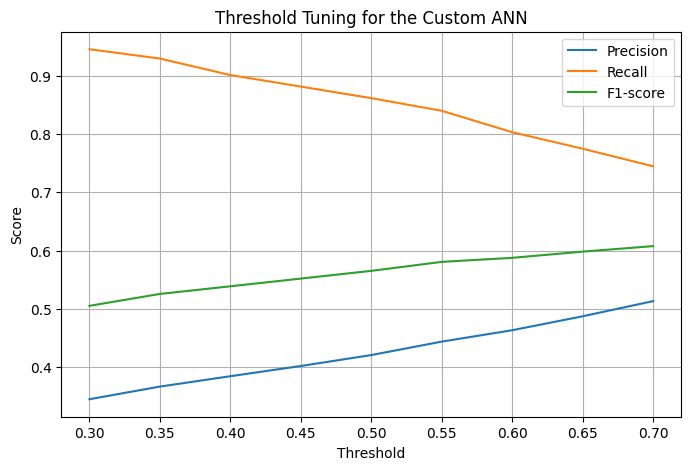

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1_score"], label="F1-score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning for the Custom ANN")
plt.grid(True)
plt.legend()
plt.show()


## D. ANN Implementation 

A library-based multipayer feedforward ANN was implemented using Scikit-learn's `MLPClassifier` with one hidden layer of 10 neurons, matching my custom ANN architecture as closely as possible. The logistic activation function was used to keep the implementation comparable to the sigmoid-based custom model, and the same preprocessed training and testing data were used for evaluation.

The Scikit-learn ANN produced the following confusion matrix:

\[
\begin{bmatrix}
7723 & 262 \\
584 & 474
\end{bmatrix}
\]

This resulted in an **accuracy of 0.9064**, **Precision of 0.6440**, **Recall of 0.4480**, and **F1-score of 0.5284**. 
Compared with the custom ANN, the sci-kit model achieved higher accuracy and precision, meaning it made fewer false positive predictions and produced more reliable positive classifications. However, its recall was much lower than that of the custom ANN, Which means it failed to identify a large proportion of actual subscribers.

These comparisons show that my custom ANN and the sci-kit ANN learned different decision behaviours. The custom model prioritised recall and detected more positive cases, whereas the sci-kit model prioritised precision and overall accuracy. 
My custom ANN is advantageous becauseit demonstrates the full mechanics of forward propagation and backpropagation, but it more difficult to tune and significantly more sensitive to threshold selection. The ski-kit ANN is easier to implement and generally more robust, but it offers less transparency into the learning process. Overall, my model is stronger for demonstrating understanding, while the ski-kit model is stronger for practical implementation.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Custom ANN | 0.8447 | 0.4203 | 0.8620 | 0.5651 |
| Library ANN | 0.9064 | 0.6440 | 0.4480 | 0.5284 |

Given that both models showed their own strenghts and weaknesses, the next stage is to explore parameter tuning and optimisation to improve predictiveperformance and achieve a better balance between **Precision** and **Recall**.

**Area under the curve for more indepth analysis**

### Import libraries

In [20]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

### Flatten target arrays for sklearn

In [21]:
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

### Library-based ANN

In [22]:
mlp = MLPClassifier(
    hidden_layer_sizes=(10,),   # one hidden layer with 10 neurons
    activation='logistic',      # closest to sigmoid
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train_flat)


MLPClassifier(activation='logistic', hidden_layer_sizes=(10,), max_iter=500,
              random_state=42)

### Predictions

In [23]:
y_pred_lib = mlp.predict(X_test)

### Metrics evaluation

In [24]:
cm_lib = confusion_matrix(y_test_flat, y_pred_lib)
acc_lib = accuracy_score(y_test_flat, y_pred_lib)
prec_lib = precision_score(y_test_flat, y_pred_lib, zero_division=0)
rec_lib = recall_score(y_test_flat, y_pred_lib, zero_division=0)
f1_lib = f1_score(y_test_flat, y_pred_lib, zero_division=0)

print("Library ANN Confusion Matrix:")
print(cm_lib)

print(f"\nAccuracy : {acc_lib:.4f}")
print(f"Precision: {prec_lib:.4f}")
print(f"Recall   : {rec_lib:.4f}")
print(f"F1-score : {f1_lib:.4f}")

Library ANN Confusion Matrix:
[[7723  262]
 [ 584  474]]

Accuracy : 0.9064
Precision: 0.6440
Recall   : 0.4480
F1-score : 0.5284


## E. Parameter Tuning and Model Optimisation

In [25]:
# Packages for grid search
from sklearn.model_selection import GridSearchCV

### Grid search for the sci-kit ANN

In [26]:
# Flatten targets
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

# Base model
mlp_tune = MLPClassifier(
    random_state=42,
    max_iter=500
)

# Parameter grid
param_grid = {
    'hidden_layer_sizes': [(10,), (15,), (20,)],
    'activation': ['logistic', 'relu'],
    'solver': ['adam'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128]
}

# Grid search
grid_search = GridSearchCV(
    estimator=mlp_tune,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train_flat)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters:
{'activation': 'relu', 'batch_size': 128, 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.1, 'solver': 'adam'}

Best Cross-Validation F1 Score:
0.569056946648595


The best parameter combination identified by the grid search was:
- **Activation:** `relu`
- **batch_size:** `128`
- **hidden_layer_sizes:** `(10,)`
- **learning_rate_init:** `0.1`
- **solver:** `adam`


### Evaluating the tunes model

In [27]:
best_mlp = grid_search.best_estimator_

y_pred_tuned = best_mlp.predict(X_test)

cm_tuned = confusion_matrix(y_test_flat, y_pred_tuned)
acc_tuned = accuracy_score(y_test_flat, y_pred_tuned)
prec_tuned = precision_score(y_test_flat, y_pred_tuned, zero_division=0)
rec_tuned = recall_score(y_test_flat, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test_flat, y_pred_tuned, zero_division=0)

print("Tuned Library ANN Confusion Matrix:")
print(cm_tuned)

print(f"\nAccuracy : {acc_tuned:.4f}")
print(f"Precision: {prec_tuned:.4f}")
print(f"Recall   : {rec_tuned:.4f}")
print(f"F1-score : {f1_tuned:.4f}")

Tuned Library ANN Confusion Matrix:
[[7626  359]
 [ 528  530]]

Accuracy : 0.9019
Precision: 0.5962
Recall   : 0.5009
F1-score : 0.5444


### Compare untuned vs tuned model

In [28]:
print("Untuned Library ANN")
print(f"Accuracy : {acc_lib:.4f}")
print(f"Precision: {prec_lib:.4f}")
print(f"Recall   : {rec_lib:.4f}")
print(f"F1-score : {f1_lib:.4f}")

print("\nTuned Library ANN")
print(f"Accuracy : {acc_tuned:.4f}")
print(f"Precision: {prec_tuned:.4f}")
print(f"Recall   : {rec_tuned:.4f}")
print(f"F1-score : {f1_tuned:.4f}")

Untuned Library ANN
Accuracy : 0.9064
Precision: 0.6440
Recall   : 0.4480
F1-score : 0.5284

Tuned Library ANN
Accuracy : 0.9019
Precision: 0.5962
Recall   : 0.5009
F1-score : 0.5444


| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Untuned Library ANN | 0.9064 | 0.6440 | 0.4480 | 0.5284 |
| Tuned Library ANN | 0.9019 | 0.5962 | 0.5009 | 0.5444 |

Parameter tuning was performed using `GridSearchCV` to improve the performance of the sci-kit based ANN, as required by the assessment brief. A total of 54 hyperparameter combinations were tested using 3-fold craoss-validation, giving 162 model fits. The parameter set was `relu` activation, batch size `128`, hidden layer size `(10,)`, learning rate `0.1`, and the `adam` solver. This combination achieved a best cross-validation F1-score of 0.5691.

The tuned model produced a confusion matrix of:

\[
\begin{bmatrix}
7626 & 359 \\
528  & 530
\end{bmatrix}
\]

This resulted in an **Accuracy = 0.9019**, **Precision = 0.5962**, **recall = 0.5009**, and an **F1-score = 0.5444**. Compared with the untuned sci-kit ANN, the tuned version achieved a slightly lower **accuracy** and **percision**, but a higher **recall** and **F1-score**. These results showing that the tuning improved the overall balance between identifying positive cases and controlling false positives. Due to the dataset being imbalances, the increase in F1-score is more meaningful than the small drop in accuracy, so the tuned model can be considered an improvement overall.

### Optimisation using Genetic Algorithm

Genetic Algorithm(GA) is an optimisation and search technique that is based around Charles Darwins theory of evolution. GA could be used to optimise the ANN by treating each candidate solution as a chromosome that represents a possible ANN configuration. These Chromosomes could encode the hyperparameters such as **Learning Rate**, **Batch Size**, **Number of hidden neurons**, **activation function**, or with more advanced inplementation that **network weights**. Each chromosome would then be evaluated using a fitness function, such as validation using F1-score, to measure how well that ANN Configuration preforms.

The proccess for GA would begin with an intial population fo randomly generated ANN configurations. Each candidate would be trained and evaluated, and its fitness score would be recorded. The best performing condidates would then be chosen as parents for the creation of the next generation. Crossover would combine parts of the two parents to create a new offspring, while a mutation would randomly alter some parameter values to maintain diversity in the search space. Over multiple generations, GA would gradually favour parameter combinations that lead to better network performance.

Comparing this to GridSearchCV, a GA offers more flexibility in ch strategy because it does not require every possible parameter combination to be tested exhoustively. This can be especially useful when the search space becomes very large of when there are multiple ANN design choices need to be optimised simultaneously. However, GAs are usually more computationally expensive, less deterministic, and mroe complex to implement than a grid search. 

```mermaid
flowchart TD
    A[Initial Population of ANN Configurations] --> B[Train and Evaluate Each ANN]
    B --> C[Calculate Fitness Score]
    C --> D[Select Best Candidates]
    D --> E[Apply Crossover and Mutation]
    E --> F[Create New Generation]
    F --> G{Stopping Condition Met?}
    G -- No --> B
    G -- Yes --> H[Return Best ANN Configuration]

**Overall**, hyperparameter tuning improved the balance of the library-based ANN, while Genetic Algorithms provide a more advanced optimisation strategy for exploring larger and more complex ANN search spaces.

### References

Brachman, R.J. and Levesque, H.J. (2004) *Knowledge Representation and Reasoning*. Morgan Kaufmann.

Medieval Warfare (n.d.) *Medieval Weapons*. Available at: https://www.medievalwarfare.info/weapons.htm (Accessed: [19/04/2026]).

Russell, S. and Norvig, P. (2021) *Artificial Intelligence: A Modern Approach*. 4th edn. Pearson.


### Overview

My Semantic Network models the medieval weapons domain using hierarchical class relationships and inherited properties. It starts from the general class `Weapon` and narrows to specific categories such as swords, bows, polearms, and blunt weapons. The purpose of the design is to represent medieval weapons in a structured way so that shared characteristics can be inherited while more specialised subclasses add their own distinguishing properties.

### Hierarchy Design

The Hierarchy begins at the root class `Weapon`, which represents the broadest category. Below this, the design separates weapons into major functional branches such as `Close Combat`, `Ranged`, `Siege` and `Personal`. To improve classification, bridge classes were introduced to support multi-inheritance. For example, `close_combat-personal` inherits from both `Close Combat` and `Personal`, while `Ranged Personal` inherits from both `Personal` and `Ranged`.

This design supports at least five levels of abstraction. One example path is:

`weapon -> personal_weapon -> close_combat_personal -> bladed_hand_weapon -> swords -> long_sword`

Another example path is:

`weapon -> personal_weapon -> ranged_personal -> mechanical_range_personal -> bow -> crossbow`

These paths show that the hierarchy moves from a very general concept to highly specific medieval weapon types.


### Properties Used in the Network
The network includes the key properties required by the brief. `weaponType` is assigned at broad levels such as `melee_weapon` and `ranged_weapon`. `primaryMaterial` is associated with groups such as bladed weapons, bows, blunt weapons, and polearms. for example, a bladed weapon will be primarily `steel` or `iron`. `effectiveRange` is represented differently for melee and ranged categories, allowing broad inherited values that can be refined further down the hierarchy. `averageWeight`, `eraUsed`, and `historicalOrigin` are most useful at lower levels or at the instance level, where a weapon can be described more precisely.

Additional attributes were also included to improve expressiveness, such as `deliveryMode`, `armorEffectiveness`, `gripType`, `projectileType`, and `throwableDesigned`. These make the network more useful for reasoning in Task 2.

### Use of Multi-Inheritance

Multi-inheritance was used to solve an issue of multiple of classes being too similar to each other when broken down.I intial had a breakdown of `Personal weapon` and `Siege` which broke down further into `close-combat` and `ranged`, this means there were two verisons of both `close-combat` and `Ranged`. to solve this I did multi-inheritance, for example `Close-combat personal` inherits from `Personal` and `Close_combat` while `close-combat Siege` inherits from `Siege` and `Close-combat`. This is the similar for `Ranged Personal` and `Ranged Siege`. This makes the network more flexible and reflects the real structure of the domain better than a single inheritance tree.


### Concrete Instance Example
The network concludes with the concrete instance `longsword_italian_15c_01`, which is an instance of `long_sword`. This instance inherits class information from `long_sword`, `swords`, `bladed_hand_weapon`, `close_combat_personal`, `melee_weapon`, and `weapon`. Through inheritance, it can be understood as a melee weapon designed for hand-strike combat, associated with bladed construction and a two-handed grip. Instance-specific values such as `averageWeight_kg = 1.6`, `eraUsed = 15thC`, and `historicalOrigin = Italy` provide a historically grounded example and demonstrate how the semantic network supports both generalisation and specificity.

### Assumptions

Some modelling assumptions were made. The class `crossbow` was kept under `bow` to preserve a simple mechanical projectile grouping, while a distinguishing attribute such as its firing or draw mechanism can separate it from hand-drawn bows. Some historical properties such as weight and effective range are approximate because real medieval weapons varied across regions and time periods. In addition, not every attribute is meaningful at every level of the hierarchy, so some properties are defined at broader class level while others are reserved for specific subclasses or instances.

### Summary

Overall, the semantic network provides a structured and extensible representation of the medieval weapons domain. It satisfies the requirement for a multi-level hierarchy, includes appropriate semantic properties, supports inheritance, and ends with a concrete instance that demonstrates how detailed weapon knowledge can be represented.